This is an example notebook for putting together a couple of key functions for a differentiable SAS model.

In [1]:
from functools import partial

import pandas as pd
import jax
import jax.numpy as jnp

import equinox as eqx
from equinox.nn import MLP, Identity, Linear

from typing import Callable

import matplotlib.pyplot as plt


# Parameter and coefficients

In [ ]:
# Number of time step
nt = 5

# Time duration
t_length = 2.

# Time step
dt = t_length / nt

# The maximum age step
τ_max = 3

# The old-water concentration
C_old = 0.5 # [mg/l]

# The first-order reaction rate constant
k1 = 0.0 

# The equilibrium concentration
C_eq = 0.0 # [mg/o]

# Outflow names
keys = 'Q'

# Fractionation
α = 1.


# Flow and solutes in/out

In [3]:
pulse_start1 = 0.05
pulse_end1 = 0.45

pulse_start2 = 1.25
pulse_end2 = 1.45

C_tracer_input1 = 0.5
C_tracer_input2 = 1.5
Q_steady = 1.
Storage_vol = 0.1

# data_df = pd.DataFrame(index=jnp.arange(nt) * dt)
# data_df['Q'] = q_steady
# data_df['J'] = q_steady
# data_df['C_J'] = c_tracer_input
# data_df.loc[pulse_start:pulse_end, 'C_J'] = 0.5
data_df = pd.DataFrame(index=jnp.arange(nt) * dt)
data_df['Q'] = Q_steady
data_df['J'] = Q_steady
data_df['C_J'] = 0
data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1
data_df.loc[pulse_start1:pulse_end1, 'J'] = Q_steady * 2
data_df.loc[pulse_start1:pulse_end1, 'Q'] = Q_steady / 20.


2025-01-16 09:48:06.190638: W external/xla/xla/service/gpu/nvptx_compiler.cc:836] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version (12.6.20). Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.
/tmp/ipykernel_1113922/3582232366.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  data_df.loc[pulse_start1:pulse_end1, 'C_J'] = C_tracer_input1


In [4]:
data_df['C_J']

0.0    0.0
0.4    0.5
0.8    0.0
1.2    0.0
1.6    0.0
Name: C_J, dtype: float64

<Axes: >

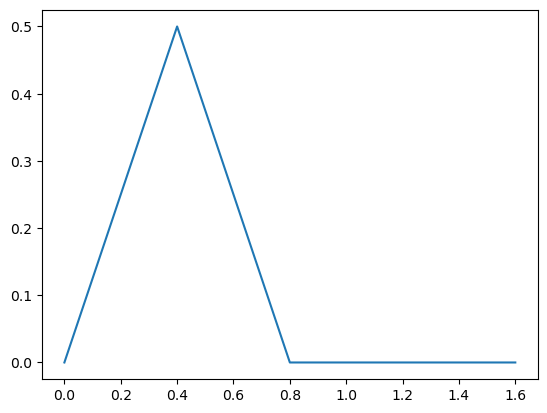

In [5]:
data_df['C_J'].plot()


# Change of flow and solute rates

In [32]:
# # Change of flow rate
# # TODO: assume only streamflow for now; add ET in the future
# def fs(sT, pQ, J_τ_t, Q_t, dt):
#     in_flow = J_τ_t
#     out_flow = Q_t * pQ
#     return (in_flow - out_flow) / dt

# # Change of solute rate
# # TODO: assume only streamflow for now; add ET in the future
# def fm(sT, mT, sas, ST, J_τ_t, C_J_τ_t, Q_t, α, k1, C_eq, dt):
#     in_sol = J_τ_t * C_J_τ_t
#     return (in_sol - mQ + mR) / dt

# Combined forward function
def f(states, ST, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt):
    sT, mT = states
    # Calculate the pQ, mQ, and mR
    PQ1, PQ2 = sas(ST+sT*dt, sas_arg), sas(ST, sas_arg)
    pQ = (PQ1 - PQ2) / dt
    mQ = compute_mQ(sT, mT, α, Q_t, pQ)
    mR = compute_mR(sT, mT, k1, C_eq)
    
    # Update the change of sT and mT
    δs = (J_τ_t - Q_t * pQ * dt) / dt

    # Update the change of sT and mT
    δm = (J_τ_t * C_J_τ_t - mQ * dt + mR * dt) / dt
    # jax.debug.print('sT: {a}; J_τ_t: {e}; ST: {f}; PQ1: {b}; PQ2: {c}; pQ: {d}', a=sT, e=J_τ_t, f=ST, b=PQ1, c=PQ2, d=pQ)
    # jax.debug.print('δs: {s}; δm: {m}', s=δs, m=δm)
    # jax.debug.print('sT: {x}; mT: {x2}; Q_t: {x3}; pQ: {x4} mQ: {s}; mR: {m}', x=sT, x2=mT, x3=Q_t, x4=pQ, s=mQ, m=mR)
    # jax.debug.print('J_τ_t, Q_t, sT, δs, pQ, ST, ST+sT*dt: {x1}, {q}, {x2}, {x3}, {a}, {b}, {c}', x1=J_τ_t, q=Q_t, x2=sT, x3=δs, a=pQ, b=ST, c=ST+sT*dt)
    # jax.debug.print('J_τ_t, Q_t, sT, δs, pQ: {x1}, {q}, {x2}, {x3}, {a}', x1=J_τ_t, q=Q_t, x2=sT, x3=δs, a=pQ)
    # jax.debug.print('J_τ_t, Q_t, sT, sT+δs*dt, ST, ST+sT*dt, pQ: {x1}, {q}, {x2}, {x3}, {x4}, {x5}, {a}', x1=J_τ_t, q=Q_t, x2=sT, x3=sT+δs*dt, x4=ST, x5=ST+sT*dt, a=pQ)
    return jnp.array([δs, δm]), pQ, mQ, mR

# fvec = jax.vmap(f, in_axes=(0,0,0,0,0,None,0,None,None,None,None))
fvec = jax.vmap(f, in_axes=(0,0,0,0,0,None,0,None,None,None,None))

In [7]:
# Compute mQ -- mass loss with flow
def compute_mQ(sT, mT, α, Q_t, pQ):
    # return mT / sT * (α * Q_t * pQ)
    # return jnp.where(sT == 0.0, 0.0, mT / sT * (α * Q_t * pQ))
    part_a = mT * (α * Q_t * pQ)
    y = jnp.where(sT == 0.0, 1.0, sT)
    part_b = jnp.where(sT == 0.0, 0.0, 1./ y)
    return part_a * part_b

# Compute mR -- Reaction rate
def compute_mR(sT, mT, k1, C_eq):
    return k1 * (C_eq*sT - mT)
    

# Data-driven SAS function

In [8]:
# # Neural likelihood?
# def sas(Si, loc=0., scale=1., t=None):
#     pass


In [9]:
# Gamma distribution
def gamma(Si, a, loc=0., scale=1.):
    return jax.scipy.stats.gamma.cdf(Si, a, loc, scale)
    

In [10]:
# Beta distribution
def beta(Si, a, b, loc=0., scale=1.):
    return jax.scipy.stats.beta.cdf(Si, a, b, loc, scale)
    # x = (Si - loc) / scale
    # return jax.scipy.special.betainc(a, b, x)
    

In [11]:
# Kumaraswamy distribution
def kumaraswamy(Si, a, b, loc=0., scale=1.):
    x = (Si - loc) / scale
    x = jax.lax.min(jax.lax.max(0., x), 1.)
    return 1. - (1. - x**a) ** b
    # return jax.scipy.special.betainc(a, b, x)
    

In [12]:
# Mixture density network
class MDN(eqx.Module):
    m: eqx.Module
    m_α: eqx.Module
    m_μ: eqx.Module
    m_σ: eqx.Module
    pdf_func: Callable
    cdf_func: Callable
    
    def __init__(self, n_input, n_hidden, n_mixture, key, **mlp_kwargs):
        key1, key2, key3, key4 = jax.random.split(key,4)
        
        # MLP model for predicting the hidden states
        # n_mlp_output = (n_output+2) * n_mixture
        self.m = MLP(in_size=n_input, out_size=n_hidden, key=key1, **mlp_kwargs)
        
        # MLP model for predicting α, μ, and σ
        self.m_α = Linear(in_features=n_hidden, out_features=n_mixture, key=key2)
        self.m_μ = Linear(in_features=n_hidden, out_features=n_mixture, key=key3)
        self.m_σ = Linear(in_features=n_hidden, out_features=n_mixture, key=key4)
        
        # PDF function of mixture distributions 
        self.pdf_func = jax.scipy.stats.norm.pdf
        
        # CDF function of mixture distributions 
        self.cdf_func = jax.scipy.stats.norm.cdf
    
    def get_param(self, x):
        # Calculate the weights, mean, and standard deviation of the mixture distributions
        z = self.m(x)  # shape: (n_hidden,)
        z_α, z_μ, z_σ = self.m_α(z), self.m_μ(z), self.m_σ(z) # shape: (n_mixture,) (n_mixture,) (n_mixture)
        
        # The weights (n_mixture,)
        α = jax.nn.softmax(z_α)
        
        # The mean (n_mixture,)
        μ = z_μ
        
        # The standard deviation (n_mixture,)
        σ = jnp.exp(z_σ)
        
        return α, μ, σ
    
    def pdf(self, y, x):
        α, μ, σ = self.get_param(x)
        pdfs = jax.vmap(self.pdf_func, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, pdfs))
    
    def __call__(self, y, x):
        α, μ, σ = self.get_param(x)
        cdfs = jax.vmap(self.cdf_func, in_axes=(None,0,0))(y, μ, σ)
        return jnp.sum(jnp.dot(α, cdfs))


In [13]:
# sas2 = partial(sas_gamma, a=0.02)
# sas1 = partial(sas_beta, a=2.31, b=0.627)
# sas1(2.)

# Explicit Euler solver

In [14]:
def solve_step_rk4(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt):
    # sT, mT, ST_top, ST_bot: (1,)
    # J_τ, C_J, Q: (nt,)
    # ST_mid = (ST_top + ST_bot) / 2

    # Note: we use relu to make sure the updated states are non-zero
    states1 = states
    ST1 = ST_top
    r1, pQ1, mQ1, mR1 = fvec(states1, ST1, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)
    
    states2 = jax.nn.relu(states+0.5*r1*dt)
    ST2 = ST_top/2 + ST_bot/2
    r2, pQ2, mQ2, mR2 = fvec(states2, ST2, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)
    
    states3 = jax.nn.relu(states+0.5*r2*dt)
    ST3 = ST_top/2 + ST_bot/2
    r3, pQ3, mQ3, mR3 = fvec(states3, ST3, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)
    
    states4 = jax.nn.relu(states+r3*dt)
    ST4 = ST_bot
    r4, pQ4, mQ4, mR4 = fvec(states4, ST4, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)
    # jax.debug.print('\n')

    states_new = jax.nn.relu(states + 1./6 * (r1 + 2 * r2 + 2 * r3 + r4) * dt)
    pQ = 1./6 * (pQ1 + 2 * pQ2 + 2 * pQ3 + pQ4)
    mQ = 1./6 * (mQ1 + 2 * mQ2 + 2 * mQ3 + mQ4)
    mR = 1./6 * (mR1 + 2 * mR2 + 2 * mR3 + mR4)
    # jax.debug.print('states: {x}', x=states)
    # jax.debug.print('states_new: {x}', x=states_new)

    return states_new, pQ, mQ, mR


In [15]:
def solve_step_rk2(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt):
    # states: (nt,2)
    # ST_top, ST_bot: (nt+1,)
    # J_τ, C_J, Q: (nt,)
    # α, k1, C_eq, dt: (1,)

    # Note: we use relu to make sure the updated states are non-zero
    ST1 = ST_top
    states1 = states
    r1, pQ1, mQ1, mR1 = fvec(states1, ST1, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)
    
    states2 = jax.nn.relu(states+1.*r1*dt)
    # states2 = states+1.*r1*dt
    ST2 = ST_bot
    r2, pQ2, mQ2, mR2 = fvec(states2, ST2, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)

    states_new = jax.nn.relu(states + (r1 + r2)/2. * dt)
    # states_new = states + (r1 + r2)/2. * dt
    pQ = 1./2 * (pQ1 + pQ2)
    mQ = 1./2 * (mQ1 + mQ2)
    mR = 1./2 * (mR1 + mR2)
    # jax.debug.print('ST1: {x6}; ST2: {x7}', x6=ST1, x7=ST2)

    return states_new, pQ, mQ, mR


In [16]:
def solve_step_euler(states, ST_top, ST_bot, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt):
    # sT, mT, ST_top, ST_bot: (1,)
    # J_τ, C_J, Q: (nt,)
    
    ST = ST_top
    r, pQ, mQ, mR = fvec(states, ST, J_τ_t, C_J_τ_t, Q_t, sas, sas_arg, α, k1, C_eq, dt)

    states_new = jax.nn.relu(states + r * dt)

    return states_new, pQ, mQ, mR


# Solve the ODE system

In [41]:
def solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, C_old, P_old,
    sas_func,
    α, k1, C_eq
):
    # Arguments
    args = [α, k1, C_eq, dt]

    # Initials at age 
    initials = [sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old]
    
    def step_age(state, x):
        # sT_init_τ : (1,,)
        # J_τ : (nt,)
        sT_init_τ, mT_init_τ, J_τ = x
    
        # sT, mT, ST, C_Q : (nt,)
        sT, mT, ST_top, ST_bot, C_Q, P_Q_old  = state
    
        # Solve the ODE system
        sT_mT = jnp.concat([sT[:,None], mT[:,None]], axis=1)
        # states_updated, pQ_new, mQ_new, mR_new = jax.vmap(
        #     solve_step_rk2, in_axes=(0,0,0,0,0,0,None,None,None,None,None))(
        #     sT_mT, ST_top[:-1], ST_bot[:-1], J_τ, C_J, Q, sas_func, *args
        # )
        sas_arg = Q
        states_updated, pQ_new, mQ_new, mR_new = solve_step_rk4(
            sT_mT, ST_top[:-1], ST_bot[1:], J_τ, C_J, Q, sas_func, sas_arg, *args
        )
        sT_new, mT_new = states_updated[:,0], states_updated[:,1]
        # jax.debug.print('sT, mT: {x1}, {x2}', x1=sT, x2=mT)
        # jax.debug.print('sT_new, mT_new: {x1}, {x2}', x1=sT_new, x2=mT_new)
        # jax.debug.print('\n')
        # jax.debug.print('sT_new, pQ_new, ST_top, ST_bot: {x1}, {x2}, {x3}, {x4}',
        #                 x1=sT_new, x2=pQ_new, x3=ST_top, x4=ST_bot)

        # Check zeros

        # Update ST
        ST_top_new = ST_bot
        ST_bot_new = jnp.concat([sT_init_τ[None] * dt, ST_bot[1:] + sT_new * dt])
        # ST_bot_new = jnp.concat([ST_bot[:-1] + sT_new * dt, (ST_bot[-1]+sT[-1]*dt)[None]])
        # ST_bot_new = jnp.concat([sT_init_τ[None], (ST_bot[-1]+sT_new[-1]*dt)[None], ST_bot[:-2] + sT_new[:-1] * dt])
        # ST_bot_new = jnp.concat([jnp.array([0]), (ST_bot[-1]+sT_new[-1]*dt)[None], ST_bot[:-2] + sT_new[:-1] * dt])
        # ST_bot_new = jnp.concat([ST_bot[:-1] + sT_new * dt, (ST_bot[-1]+sT_new[-1]*dt)[None]])
    
        # Update P_Q
        P_Q_old_new = P_Q_old - pQ_new * dt
        
        # Update C_Q
        C_Q_new = C_Q + mQ_new * dt / Q
        
        # Variables to save
        state_to_save = [sT_new, mT_new, mQ_new, pQ_new, C_Q_new, P_Q_old_new]
    
        # Variables as the initial condition to the next step
        sT_new_rotate = jnp.concat([sT_init_τ[None],sT_new[:-1]])
        mT_new_rotate = jnp.concat([mT_init_τ[None],mT_new[:-1]])
    
        state_to_rotate = [sT_new_rotate, mT_new_rotate, ST_top_new, ST_bot_new, C_Q_new, P_Q_old_new]
        
        return state_to_rotate, state_to_save
    
    _, states = jax.lax.scan(step_age, initials, [sT_init, mT_init, J_full])
    
    sT, mT, mQ, pQ, C_Q, P_Q_old = states

    sT = jnp.concat([sT_init[:,None], sT], axis=1)
    mT = jnp.concat([mT_init[:,None], mT], axis=1)
    
    print(pQ)
    print(P_Q_old)
    
    # Add old age concentration to C_Q
    C_Q = C_Q[-1] + C_old * P_Q_old[-1]

    # # Get the exact flux extracted at each age step
    # pQ_flux = pQ * dt * Q

    return sT, mT, mQ, C_Q, pQ


# Run SAS

In [42]:
C_J = jnp.array(data_df['C_J'].values) # (nt)
Q = jnp.array(data_df['Q'].values) # (nt,)
J = jnp.array(data_df['J'].values) # (nt,)
J_full = jnp.concat([J[None,:], jnp.zeros([τ_max-1, nt])])

# Initial sT and mT at time = 0
# sT_init, mT_init = jnp.zeros(τ_max), jnp.zeros(τ_max)
sT_init, mT_init = jnp.array([10., 15., 20.]), jnp.array([10., 10., 10.])

# Initials at age = 0
sT_0, mT_0 = jnp.zeros(nt), jnp.zeros(nt)
ST_top_0, ST_bot_0 = jnp.zeros(nt+1), jnp.zeros(nt+1) 
C_Q_0, P_old = jnp.zeros(nt), jnp.ones(nt) 
# initials = [sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old]

# SAS function
# sas_func = partial(sas_gamma, a=0.02)
# sas_func = partial(sas_beta, a=2.31, b=0.627)



## Kumaraswamy

In [43]:
# sas_func = partial(kumaraswamy, a=2.31, b=0.627)
def sas_func(Si, sas_args, a=2.31, b=0.627, loc=0., scale=1., ):
    return kumaraswamy(Si, a=a, b=b, loc=loc, scale=scale)

In [48]:
sT_final, mT_final, mQ_final, C_Q_final, pQ_final = solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, C_old, P_old,
    sas_func,
    α, k1, C_eq
)
# sT_final, mT_final, mQ_final, C_Q_final, pQ_final
C_Q_final

[[0.0561477  0.30865917 0.0561477  0.0561477  0.0561477 ]
 [2.4452848  0.833573   1.4578216  0.40462017 0.40462017]
 [0.         1.3620644  1.0564804  1.7181284  0.7589163 ]]
[[ 9.7754091e-01  8.7653631e-01  9.7754091e-01  9.7754091e-01
   9.7754091e-01]
 [-5.7309866e-04  5.4310715e-01  3.9441228e-01  8.1569284e-01
   8.1569284e-01]
 [-5.7309866e-04 -1.7186403e-03 -2.8179884e-02  1.2844145e-01
   5.1212633e-01]]


Array([0.9778274 , 0.60569835, 0.27747437, 0.40784642, 0.25606316],      dtype=float32)

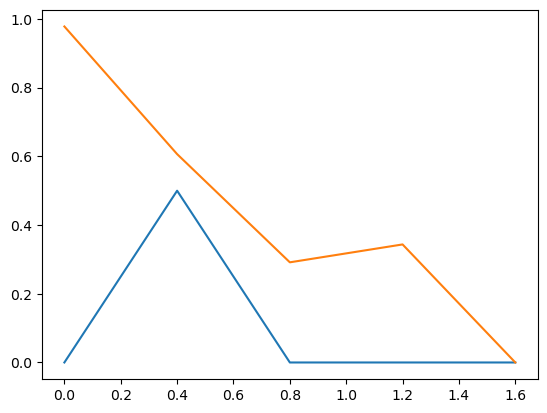

In [108]:
plt.plot(data_df.index, data_df['C_J'])
plt.plot(data_df.index, C_Q_final)


## Gamma

In [24]:
def sas_func(Si, sas_args, a=0.02, loc=0., scale=1., ):
    return gamma(Si, a=0.02, loc=0., scale=1.)

In [25]:
sT_final, mT_final, mQ_final, C_Q_final, pQ_final = solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old,
    sas_func,
    α, k1, C_eq
)
sT_final, mT_final, mQ_final, C_Q_final, pQ_final


sT: 0.0; J_τ_t: 2.0; ST: 0.0; PQ1: 0.0; PQ2: 0.0; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.0; PQ2: 0.0; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.0; PQ2: 0.0; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.0; PQ2: 0.0; pQ: 0.0
sT: 1.0; J_τ_t: 2.0; ST: 0.0; PQ1: 0.9858518838882446; PQ2: 0.0; pQ: 2.464629650115967
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9755940437316895; PQ2: 0.0; pQ: 2.4389851093292236
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9755940437316895; PQ2: 0.0; pQ: 2.4389851093292236
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9755940437316895; PQ2: 0.0; pQ: 2.4389851093292236
sT: 0.9753537178039551; J_τ_t: 2.0; ST: 0.0; PQ1: 0.985518217086792; PQ2: 0.0; pQ: 2.4637956619262695
sT: 0.012202978134155273; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9090784192085266; PQ2: 0.0; pQ: 2.272696018218994
sT: 0.012202978134155273; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9090784192085266; PQ2: 0.0; pQ: 2.272696018218994
sT: 0.012202978134155273; J_τ_t: 1.0; ST: 0.0; PQ1: 0.9090784192085266; PQ2: 0.0; pQ: 2.272696018218994
sT:

(Array([[10.        ,  0.21414958,  1.958865  ,  0.21414958,  0.21414958,
          0.21414958],
        [15.        ,  9.792774  ,  0.20605114,  1.7585477 ,  0.0455932 ,
          0.0455932 ],
        [20.        , 14.999921  ,  9.792009  ,  0.20517403,  1.7279083 ,
          0.04261091]], dtype=float32),
 Array([[10.        ,  0.        ,  0.9794325 ,  0.        ,  0.        ,
          0.        ],
        [10.        ,  9.792774  ,  0.        ,  0.8792738 ,  0.        ,
          0.        ],
        [10.        ,  9.999948  ,  9.792009  ,  0.        ,  0.86395407,
          0.        ]], dtype=float32),
 Array([[0.0000000e+00, 5.1418703e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00],
        [5.1806432e-01, 0.0000000e+00, 2.5039679e-01, 0.0000000e+00,
         0.0000000e+00],
        [1.3113022e-04, 1.9121580e-03, 0.0000000e+00, 3.8299263e-02,
         0.0000000e+00]], dtype=float32),
 Array([0.20727818, 0.42664692, 0.10015872, 0.01531971, 0.        ],      dtype=float

In [ ]:
plt.plot(data_df.index, data_df['C_J'])
plt.plot(data_df.index, C_Q_final)


## MDN

In [22]:
n_input, n_hidden, n_mixture, key = 1, 20, 5, jax.random.key(42)
mlp_kwargs = {"width_size": 20, "depth":3}

sas_model = MDN(n_input, n_hidden, n_mixture, key, **mlp_kwargs)

def sas_func(Si, Q, loc=0., scale=1., ):
    y = (Si - loc) / scale
    return sas_model(jnp.array([y]), jnp.array([Q]))


In [23]:
sT_final, mT_final, mQ_final, C_Q_final, pQ_final = solve_sas(
    J_full, C_J, Q, J, dt,
    sT_init, mT_init,
    sT_0, mT_0, ST_top_0, ST_bot_0, C_Q_0, P_old,
    sas_func,
    α, k1, C_eq
)
sT_final, mT_final, mQ_final, C_Q_final, pQ_final


sT: 0.0; J_τ_t: 2.0; ST: 0.0; PQ1: 0.4530791938304901; PQ2: 0.4530791938304901; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.4549557566642761; PQ2: 0.4549557566642761; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.4549557566642761; PQ2: 0.4549557566642761; pQ: 0.0
sT: 0.0; J_τ_t: 1.0; ST: 0.0; PQ1: 0.4549557566642761; PQ2: 0.4549557566642761; pQ: 0.0
sT: 1.0; J_τ_t: 2.0; ST: 0.0; PQ1: 0.6255916357040405; PQ2: 0.4530791938304901; pQ: 0.43128108978271484
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.5421725511550903; PQ2: 0.4549557566642761; pQ: 0.21804198622703552
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.5421725511550903; PQ2: 0.4549557566642761; pQ: 0.21804198622703552
sT: 0.5; J_τ_t: 1.0; ST: 0.0; PQ1: 0.5421725511550903; PQ2: 0.4549557566642761; pQ: 0.21804198622703552
sT: 0.9956871867179871; J_τ_t: 2.0; ST: 0.0; PQ1: 0.6248753666877747; PQ2: 0.4530791938304901; pQ: 0.42949044704437256
sT: 0.4563916325569153; J_τ_t: 1.0; ST: 0.0; PQ1: 0.5345756411552429; PQ2: 0.4549557566642761; pQ: 0.199049711227

(Array([[10.        ,  0.91784406,  1.9915874 ,  0.91784406,  0.91784406,
          0.91784406],
        [15.        ,  9.534829  ,  0.91108376,  1.7135769 ,  0.7769894 ,
          0.7769894 ],
        [20.        , 14.999974  ,  9.522647  ,  0.8289659 ,  1.515376  ,
          0.6737775 ]], dtype=float32),
 Array([[10.        ,  0.        ,  0.9957937 ,  0.        ,  0.        ,
          0.        ],
        [10.        ,  9.534829  ,  0.        ,  0.85678846,  0.        ,
          0.        ],
        [10.        ,  9.999983  ,  9.522647  ,  0.        ,  0.757688  ,
          0.        ]], dtype=float32),
 Array([[0.0000000e+00, 1.0515684e-02, 0.0000000e+00, 0.0000000e+00,
         0.0000000e+00],
        [1.1629274e+00, 0.0000000e+00, 3.4751314e-01, 0.0000000e+00,
         0.0000000e+00],
        [4.2832558e-05, 3.0456236e-02, 0.0000000e+00, 2.4775118e-01,
         0.0000000e+00]], dtype=float32),
 Array([0.46518812, 0.32777536, 0.13900526, 0.09910048, 0.        ],      dtype=float

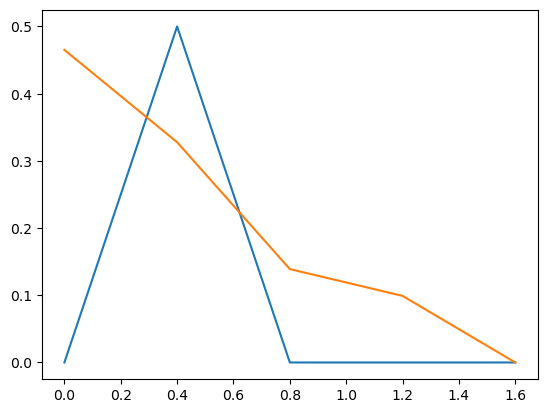

In [102]:
plt.plot(data_df.index, data_df['C_J'])
plt.plot(data_df.index, C_Q_final)


In [ ]:
# # Compute mQ -- mass loss with flow
# def compute_mQ(sT, mT, α, Q_t, pQ):
#     # return mT / sT * (α * Q_t * pQ)
#     part_a = mT * (α * Q_t * pQ)
#     y = jnp.where(sT == 0.0, 1.0, sT)
#     part_b = jnp.where(sT == 0.0, 0.0, 1./ y)
#     return part_a * part_b
